# Linear Regression


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## 1. 線性迴歸基本概念

#### 直線

$$f(x) = 1.2x + 0.8$$



In [33]:
#準備 50 個點
#5-0/50 = 0.1 +....
# 0~5線性切割
x = np.linspace(0, 5, 50)
print(x)

[0.         0.10204082 0.20408163 0.30612245 0.40816327 0.51020408
 0.6122449  0.71428571 0.81632653 0.91836735 1.02040816 1.12244898
 1.2244898  1.32653061 1.42857143 1.53061224 1.63265306 1.73469388
 1.83673469 1.93877551 2.04081633 2.14285714 2.24489796 2.34693878
 2.44897959 2.55102041 2.65306122 2.75510204 2.85714286 2.95918367
 3.06122449 3.16326531 3.26530612 3.36734694 3.46938776 3.57142857
 3.67346939 3.7755102  3.87755102 3.97959184 4.08163265 4.18367347
 4.28571429 4.3877551  4.48979592 4.59183673 4.69387755 4.79591837
 4.89795918 5.        ]


In [34]:
y = 1.2*x + 0.8
y

array([0.8       , 0.92244898, 1.04489796, 1.16734694, 1.28979592,
       1.4122449 , 1.53469388, 1.65714286, 1.77959184, 1.90204082,
       2.0244898 , 2.14693878, 2.26938776, 2.39183673, 2.51428571,
       2.63673469, 2.75918367, 2.88163265, 3.00408163, 3.12653061,
       3.24897959, 3.37142857, 3.49387755, 3.61632653, 3.73877551,
       3.86122449, 3.98367347, 4.10612245, 4.22857143, 4.35102041,
       4.47346939, 4.59591837, 4.71836735, 4.84081633, 4.96326531,
       5.08571429, 5.20816327, 5.33061224, 5.45306122, 5.5755102 ,
       5.69795918, 5.82040816, 5.94285714, 6.06530612, 6.1877551 ,
       6.31020408, 6.43265306, 6.55510204, 6.67755102, 6.8       ])

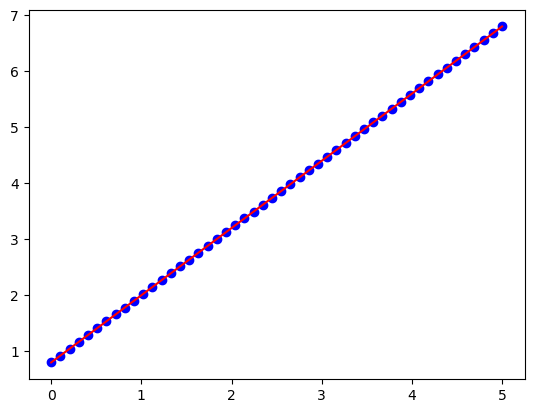

In [35]:
#畫圖
plt.scatter(x,y,color='b')
plt.plot(x, 1.2*x+0.8, 'r')
plt.show()

#### add noise 

$$f(x) + \varepsilon(x)$$


In [36]:
y = 1.2*x + 0.8 + 0.6*np.random.randn(50)
print(y)

[ 1.53381025  1.18862146  1.26729654  1.11359801 -0.18949362  1.51382011
  0.777372    2.05462429  2.35702645  2.12875217  1.28271775  1.45476843
  1.66404712  2.61125493  2.63590748  2.21124866  3.06281816  2.48316009
  3.32156721  2.65988035  1.4587975   2.04890239  3.65441607  3.18235504
  3.83072113  3.35241628  4.52797799  3.52522612  4.64717862  4.61138855
  3.92882742  5.06618847  2.92827189  4.18735177  5.2709548   5.37010597
  5.62316099  6.1228239   5.53527047  5.81263263  5.72809771  6.021731
  5.63680829  5.76749989  6.81328112  6.768288    5.64042352  5.52658971
  7.63149257  7.23810634]


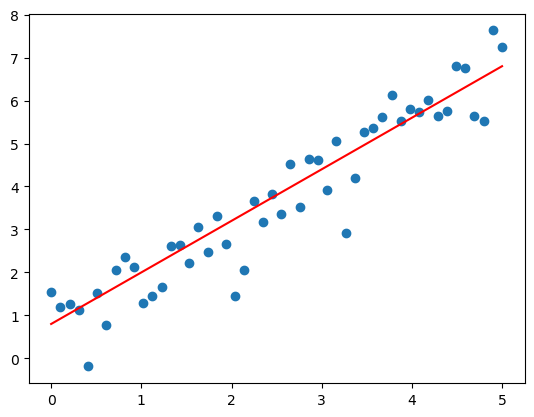

In [37]:
plt.scatter(x,y)
plt.plot(x, 1.2*x + 0.8, 'r')
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression
regr = LinearRegression()

In [16]:
regr

LinearRegression()

要求資料轉換<br>

$$[x_1, x_2, \ldots, x_{50}]$$

==> 「一維數列（1D Array）」轉化為「二維矩陣（2D Matrix）」

$$[[x_1], [x_2], \ldots, [x_{50}]]$$


矩陣的概念

In [38]:
print(x.shape) #(50,) 一維數列（1D Array）線性
X = x.reshape(-1,1) #轉化為「二維矩陣（2D Matrix）」，（row, column)，-1 (列數)：自動佔位，1 (Column)。
X.shape #50 row, 1 column

(50,)


(50, 1)

In [39]:
regr.fit(X,y)

LinearRegression()

In [40]:
Y = regr.predict(X)
print(Y)

[0.57078481 0.69817325 0.8255617  0.95295014 1.08033858 1.20772703
 1.33511547 1.46250392 1.58989236 1.7172808  1.84466925 1.97205769
 2.09944613 2.22683458 2.35422302 2.48161146 2.60899991 2.73638835
 2.8637768  2.99116524 3.11855368 3.24594213 3.37333057 3.50071901
 3.62810746 3.7554959  3.88288435 4.01027279 4.13766123 4.26504968
 4.39243812 4.51982656 4.64721501 4.77460345 4.90199189 5.02938034
 5.15676878 5.28415723 5.41154567 5.53893411 5.66632256 5.793711
 5.92109944 6.04848789 6.17587633 6.30326478 6.43065322 6.55804166
 6.68543011 6.81281855]


In [41]:
#了解你的訓練參數
regr.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

0.4091691959378798


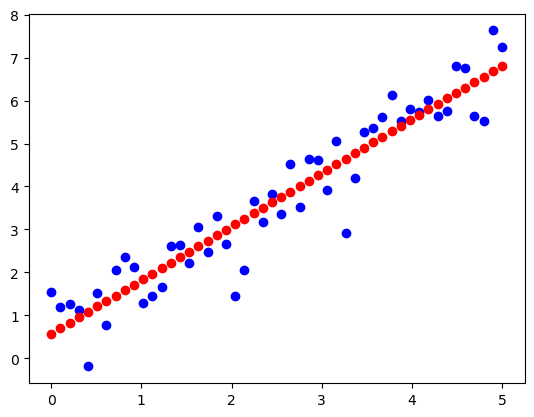

In [44]:
plt.scatter(x, y,color='b') #原本 
plt.plot(x, Y, 'ro') #預測
#calculate mse (mean squar error) 

mse = np.sum((Y-y)**2) / len(y)
print(mse)
plt.show()

In [45]:
#Y=WX+b
W=regr.coef_#斜率
W



array([1.24840675])

In [46]:
b=regr.intercept_ #截距
b

np.float64(0.5707848093850512)

In [47]:
Y

array([0.57078481, 0.69817325, 0.8255617 , 0.95295014, 1.08033858,
       1.20772703, 1.33511547, 1.46250392, 1.58989236, 1.7172808 ,
       1.84466925, 1.97205769, 2.09944613, 2.22683458, 2.35422302,
       2.48161146, 2.60899991, 2.73638835, 2.8637768 , 2.99116524,
       3.11855368, 3.24594213, 3.37333057, 3.50071901, 3.62810746,
       3.7554959 , 3.88288435, 4.01027279, 4.13766123, 4.26504968,
       4.39243812, 4.51982656, 4.64721501, 4.77460345, 4.90199189,
       5.02938034, 5.15676878, 5.28415723, 5.41154567, 5.53893411,
       5.66632256, 5.793711  , 5.92109944, 6.04848789, 6.17587633,
       6.30326478, 6.43065322, 6.55804166, 6.68543011, 6.81281855])

In [48]:
#可以將新的x資料帶入算出結果
W*3+b

array([4.31600505])

In [49]:
y

array([ 1.53381025,  1.18862146,  1.26729654,  1.11359801, -0.18949362,
        1.51382011,  0.777372  ,  2.05462429,  2.35702645,  2.12875217,
        1.28271775,  1.45476843,  1.66404712,  2.61125493,  2.63590748,
        2.21124866,  3.06281816,  2.48316009,  3.32156721,  2.65988035,
        1.4587975 ,  2.04890239,  3.65441607,  3.18235504,  3.83072113,
        3.35241628,  4.52797799,  3.52522612,  4.64717862,  4.61138855,
        3.92882742,  5.06618847,  2.92827189,  4.18735177,  5.2709548 ,
        5.37010597,  5.62316099,  6.1228239 ,  5.53527047,  5.81263263,
        5.72809771,  6.021731  ,  5.63680829,  5.76749989,  6.81328112,
        6.768288  ,  5.64042352,  5.52658971,  7.63149257,  7.23810634])